In [13]:
# ============================================================
# 1. Imports
# ============================================================

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.ipc as ipc
import pickle
import msgpack
import json
import time
import os
import io
import sqlite3
import h5py
import tempfile
import matplotlib.pyplot as plt

In [14]:
# ==============================================
# 1.5 Output Directories
# ==============================================

from pathlib import Path

# ------------------------------------------------
# Base project directory
# ------------------------------------------------

BASE_DIR = Path.cwd().parent

# ------------------------------------------------
# Serialization results directory
# ------------------------------------------------

RESULTS_DIR = (
    BASE_DIR /
    "results" /
    "serialization"
)

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

# ------------------------------------------------
# Create directories if missing
# ------------------------------------------------

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")


Results directory: /home/megh/arrow-ipc-analysis-linux/results/serialization


In [15]:

# ============================================================
# 2. Create Dataset
# ============================================================

# IMPORTANT:
# Start with 1 million rows first.
# Increase later if stable.

n_rows = 1_000_000

print("="*70)
print(f"Creating dataset with {n_rows:,} rows...")
print("="*70)

categories = ['catA', 'catB', 'catC', 'catD', 'catE'] * (n_rows // 5)

ids = np.arange(n_rows)

texts = ['text_' + str(i % 100) for i in range(n_rows)]

df = pd.DataFrame({
    'category': categories,
    'id': ids,
    'text': texts,
    'float_col': np.random.randn(n_rows)
})

# ------------------------------------------------------------
# Arrow-optimized dataframe
# ------------------------------------------------------------

df_arrow = df.copy()

df_arrow['category'] = df_arrow['category'].astype('string[pyarrow]')

df_arrow['text'] = df_arrow['text'].astype('string[pyarrow]')

print(df.head())

Creating dataset with 1,000,000 rows...
  category  id    text  float_col
0     catA   0  text_0   0.332285
1     catB   1  text_1  -2.235788
2     catC   2  text_2  -0.674902
3     catD   3  text_3  -1.279160
4     catE   4  text_4  -1.857441


In [16]:

# ============================================================
# 3. Benchmark Helper Function
# ============================================================

def measure_serde(ser_func, deser_func, name):

    # --------------------------------------------------------
    # Serialization
    # --------------------------------------------------------

    start = time.perf_counter()

    serialised = ser_func()

    ser_time = time.perf_counter() - start

    # --------------------------------------------------------
    # Deserialization
    # --------------------------------------------------------

    start = time.perf_counter()

    deser_func(serialised)

    deser_time = time.perf_counter() - start

    # --------------------------------------------------------
    # Determine serialized size
    # --------------------------------------------------------

    if isinstance(serialised, (bytes, pa.Buffer)):

        size_mb = len(serialised) / 1024**2

    elif isinstance(serialised, str) and os.path.exists(serialised):

        size_mb = os.path.getsize(serialised) / 1024**2

    else:

        size_mb = -1

    return (
        name,
        ser_time,
        deser_time,
        size_mb
    )


In [17]:
# ============================================================
# 4. Temporary Directory
# ============================================================

temp_dir = tempfile.TemporaryDirectory()

temp_path = temp_dir.name

In [18]:

# ============================================================
# 5. Run Benchmarks
# ============================================================

results = []

# ============================================================
# Arrow IPC
# ============================================================

print("\nRunning Arrow IPC benchmark...")

table = pa.Table.from_pandas(df_arrow)

def ser_arrow():

    sink = pa.BufferOutputStream()

    writer = ipc.new_stream(
        sink,
        table.schema
    )

    writer.write_table(table)

    writer.close()

    return sink.getvalue()

def deser_arrow(buf):

    ipc.open_stream(buf).read_all()

results.append(
    measure_serde(
        ser_arrow,
        deser_arrow,
        "Arrow IPC"
    )
)

# ============================================================
# NumPy .npy
# ============================================================

print("Running NumPy benchmark...")

numeric_arr = df[['id', 'float_col']].to_numpy()

def ser_numpy():

    buf = io.BytesIO()

    np.save(buf, numeric_arr)

    return buf.getvalue()

def deser_numpy(buf):

    np.load(io.BytesIO(buf))

results.append(
    measure_serde(
        ser_numpy,
        deser_numpy,
        "NumPy .npy"
    )
)

# ============================================================
# MessagePack
# ============================================================

print("Running MessagePack benchmark...")

def ser_msgpack():

    return msgpack.packb({
        'category': df['category'].tolist(),
        'id': df['id'].tolist(),
        'text': df['text'].tolist(),
        'float_col': df['float_col'].tolist()
    })

def deser_msgpack(buf):

    data = msgpack.unpackb(buf)

    pd.DataFrame(data)

results.append(
    measure_serde(
        ser_msgpack,
        deser_msgpack,
        "MessagePack"
    )
)

# ============================================================
# JSON
# ============================================================

print("Running JSON benchmark...")

def ser_json():

    return json.dumps({
        'category': df['category'].tolist(),
        'id': df['id'].tolist(),
        'text': df['text'].tolist(),
        'float_col': df['float_col'].tolist()
    }).encode('utf-8')

def deser_json(buf):

    data = json.loads(buf.decode('utf-8'))

    pd.DataFrame(data)

results.append(
    measure_serde(
        ser_json,
        deser_json,
        "JSON"
    )
)

# ============================================================
# Pickle
# ============================================================

print("Running Pickle benchmark...")

def ser_pickle():

    return pickle.dumps(
        df,
        protocol=pickle.HIGHEST_PROTOCOL
    )

def deser_pickle(buf):

    pickle.loads(buf)

results.append(
    measure_serde(
        ser_pickle,
        deser_pickle,
        "Pickle"
    )
)

# ============================================================
# CSV
# ============================================================

print("Running CSV benchmark...")

csv_path = os.path.join(
    temp_path,
    'temp.csv'
)

def ser_csv():

    df.to_csv(
        csv_path,
        index=False
    )

    return csv_path

def deser_csv(path):

    pd.read_csv(path)

results.append(
    measure_serde(
        ser_csv,
        deser_csv,
        "CSV"
    )
)

# ============================================================
# SQLite
# ============================================================

print("Running SQLite benchmark...")

db_path = os.path.join(
    temp_path,
    'temp.db'
)

def ser_sqlite():

    conn = sqlite3.connect(db_path)

    df.to_sql(
        'data',
        conn,
        if_exists='replace',
        index=False
    )

    conn.close()

    return db_path

def deser_sqlite(path):

    conn = sqlite3.connect(path)

    pd.read_sql(
        'SELECT * FROM data',
        conn
    )

    conn.close()

results.append(
    measure_serde(
        ser_sqlite,
        deser_sqlite,
        "SQLite"
    )
)

# ============================================================
# HDF5
# ============================================================

print("Running HDF5 benchmark...")

h5_path = os.path.join(
    temp_path,
    'temp.h5'
)

def ser_hdf5():

    df.to_hdf(
        h5_path,
        key='df',
        mode='w',
        complevel=9,
        complib='blosc'
    )

    return h5_path

def deser_hdf5(path):

    pd.read_hdf(
        path,
        'df'
    )

results.append(
    measure_serde(
        ser_hdf5,
        deser_hdf5,
        "HDF5"
    )
)

# ============================================================
# Parquet
# ============================================================

print("Running Parquet benchmark...")

pq_path = os.path.join(
    temp_path,
    'temp.parquet'
)

def ser_parquet():

    df.to_parquet(
        pq_path,
        compression='None'
    )

    return pq_path

def deser_parquet(path):

    pd.read_parquet(path)

results.append(
    measure_serde(
        ser_parquet,
        deser_parquet,
        "Parquet"
    )
)


Running Arrow IPC benchmark...
CUSTOM IPC BUILD ACTIVE
Running NumPy benchmark...
Running MessagePack benchmark...
Running JSON benchmark...
Running Pickle benchmark...
Running CSV benchmark...
Running SQLite benchmark...
Running HDF5 benchmark...
Running Parquet benchmark...


In [19]:
# ============================================================
# 6. Results Table
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Format",
        "Serialization_Time_s",
        "Deserialization_Time_s",
        "Size_MB"
    ]
)

results_df = results_df.sort_values(
    by="Serialization_Time_s"
)

print("\n")
print("="*90)
print("FINAL RESULTS")
print("="*90)

print(results_df)




FINAL RESULTS
        Format  Serialization_Time_s  Deserialization_Time_s    Size_MB
1   NumPy .npy              0.050753                0.096382  15.258911
4       Pickle              0.052214                0.008358  40.913827
8      Parquet              0.161013                0.156280  16.987189
0    Arrow IPC              0.318887                0.001700  40.914032
7         HDF5              0.678666                0.428576  23.577998
2  MessagePack              0.682558                0.822648  25.528519
3         JSON              0.955273                0.978685  45.224098
5          CSV              1.772848                0.398386  37.594685
6       SQLite              2.953303                1.533381  31.542969


In [20]:
# ==============================================
# 7. Save Results CSV
# ==============================================

results_csv_path = (
    TABLES_DIR /
    "serialization_results.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print(
    f"\nSaved results to:\n{results_csv_path}"
)





Saved results to:
/home/megh/arrow-ipc-analysis-linux/results/serialization/tables/serialization_results.csv


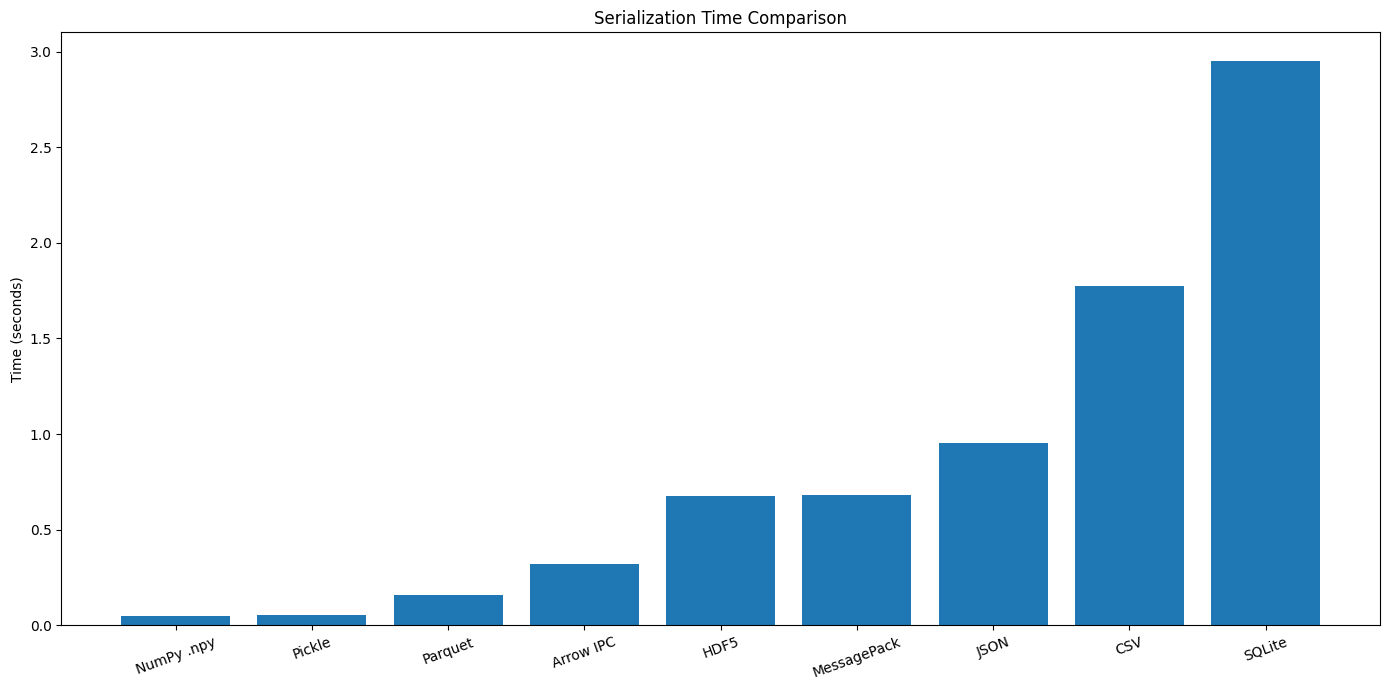

In [21]:

# ============================================================
# 8. Serialization Time Graph
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Format"],
    results_df["Serialization_Time_s"]
)

plt.title("Serialization Time Comparison")

plt.ylabel("Time (seconds)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()



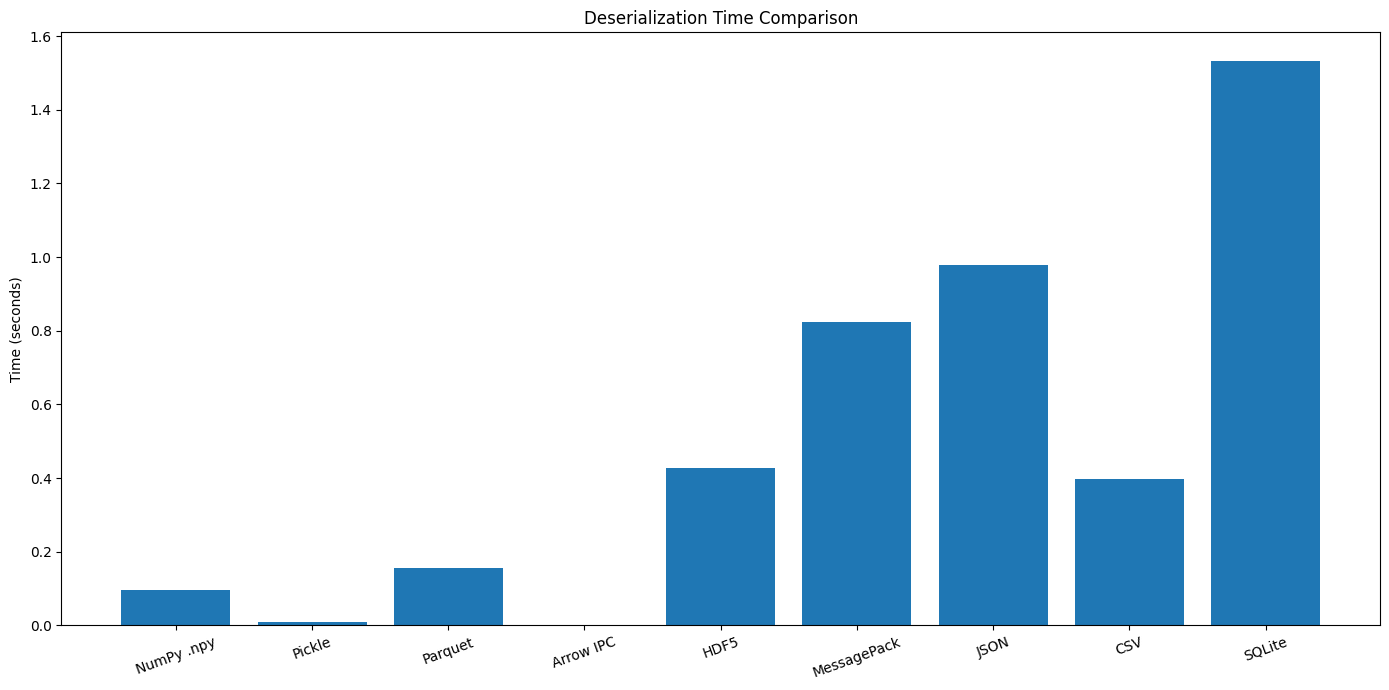

In [22]:

# ============================================================
# 9. Deserialization Time Graph
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Format"],
    results_df["Deserialization_Time_s"]
)

plt.title("Deserialization Time Comparison")

plt.ylabel("Time (seconds)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig( GRAPHS_DIR / "deserialization_time.png", dpi=300, bbox_inches="tight" )
plt.show()


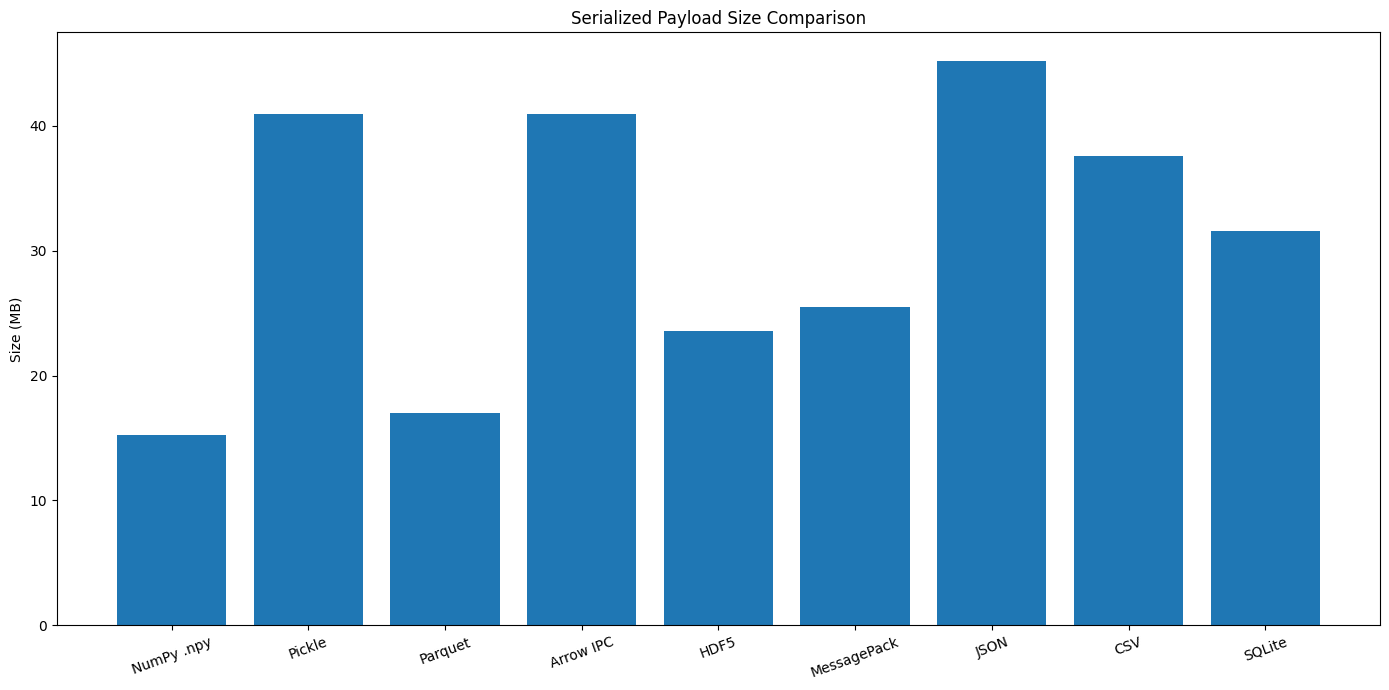

In [23]:
# ============================================================
# 10. Serialized Size Graph
# ============================================================

plt.figure(figsize=(14, 7))

plt.bar(
    results_df["Format"],
    results_df["Size_MB"]
)

plt.title("Serialized Payload Size Comparison")

plt.ylabel("Size (MB)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig( GRAPHS_DIR / "serialized_size.png", dpi=300, bbox_inches="tight" ) 
plt.show()


In [24]:

# ============================================================
# 11. Cleanup
# ============================================================

temp_dir.cleanup()

print("\nTemporary files cleaned up.")

print("\nExperiment completed successfully.")


Temporary files cleaned up.

Experiment completed successfully.
